In [1]:
## 306 project
#install.packages("dplyr")
library(dplyr)
#install.packages("ggplot2")
library(ggplot2)
#install.packages("tidyverse")
library(tidyverse)
library(patchwork)
#install.packages("car")
library(car)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.2.0     ✔ tidyr     1.3.2
✔ readr     2.1.6     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:purrr’:

    some


The following object is masked from ‘package:dplyr’:

    recode




In [2]:
# Load Data
yield_data <- read.csv("cereal-crop-yield-vs-fertilizer-application.csv")
co_data    <- read.csv("co-emissions-per-capita.csv")
gdp_data   <- read.csv("gdp-per-capita-worldbank.csv")

In [3]:
# Clean data and organize into one data frame
avg_yield <- yield_data %>%
  filter(Year >= 2019) %>%
  group_by(Entity, region = World.region.according.to.OWID) %>%
  summarise(mean_yield = mean(Cereal.yield, na.rm = TRUE), .groups = "drop")

avg_co <- co_data %>%
  filter(Year >= 2019) %>%
  group_by(Entity) %>%
  summarise(mean_co = mean(CO..emissions.per.capita, na.rm = TRUE), .groups = "drop")

avg_gdp <- gdp_data %>%
  filter(Year >= 2019) %>%
  group_by(Entity) %>%
  summarise(mean_gdp = mean(GDP.per.capita, na.rm = TRUE), .groups = "drop")

model_df <- avg_yield %>%
  inner_join(avg_co, by = "Entity") %>%
  inner_join(avg_gdp, by = "Entity") %>%
  filter(!is.na(region)) %>%
 filter(mean_yield > 0, mean_co > 0, mean_gdp > 0, region != "")


    Entity             region            mean_yield          mean_co        
 Length:170         Length:170         Min.   : 0.02167   Min.   : 0.04994  
 Class :character   Class :character   1st Qu.: 1.65163   1st Qu.: 0.75359  
 Mode  :character   Mode  :character   Median : 3.20280   Median : 2.53943  
                                       Mean   : 3.80317   Mean   : 4.29831  
                                       3rd Qu.: 5.04743   3rd Qu.: 5.62626  
                                       Max.   :24.27842   Max.   :38.12798  
    mean_gdp     
 Min.   :  1040  
 1st Qu.:  5618  
 Median : 15572  
 Mean   : 23688  
 3rd Qu.: 35197  
 Max.   :131743  


       Africa          Asia        Europe North America       Oceania 
           50            43            39            20             7 
South America 
           11 

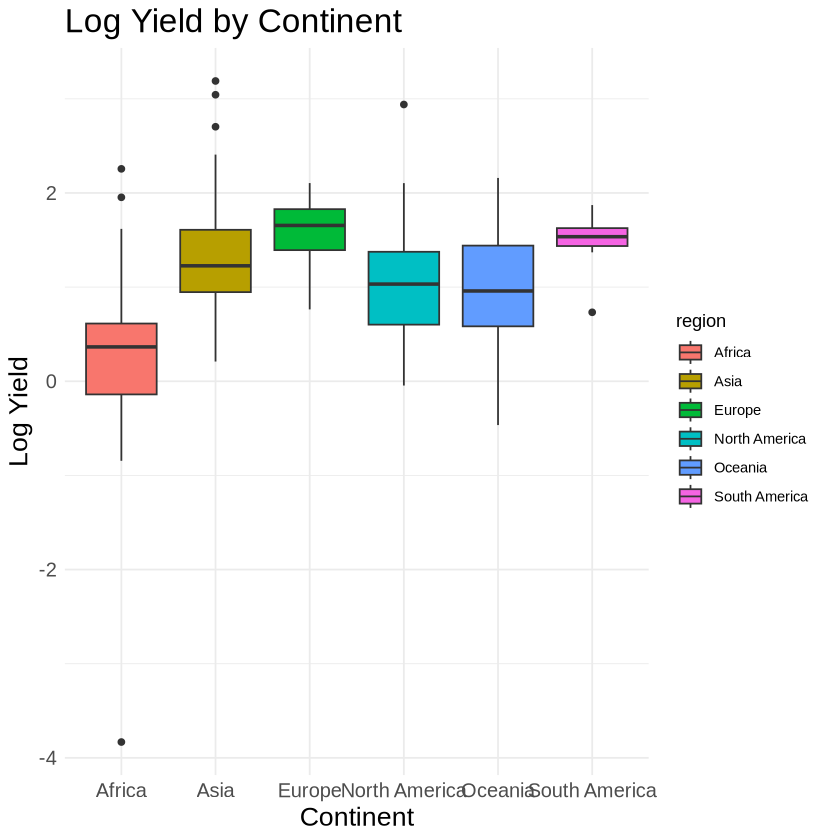

In [5]:
# 3. Summary Statistic
summary(model_df)
table(model_df$region)


ggplot(model_df, aes(x = region, y = log(mean_yield), fill = region)) +
  geom_boxplot() +
  labs(
    title = "Log Yield by Continent",
    x = "Continent",
    y = "Log Yield"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 20),
    axis.title = element_text(size = 16),
    axis.text  = element_text(size = 12)
  )

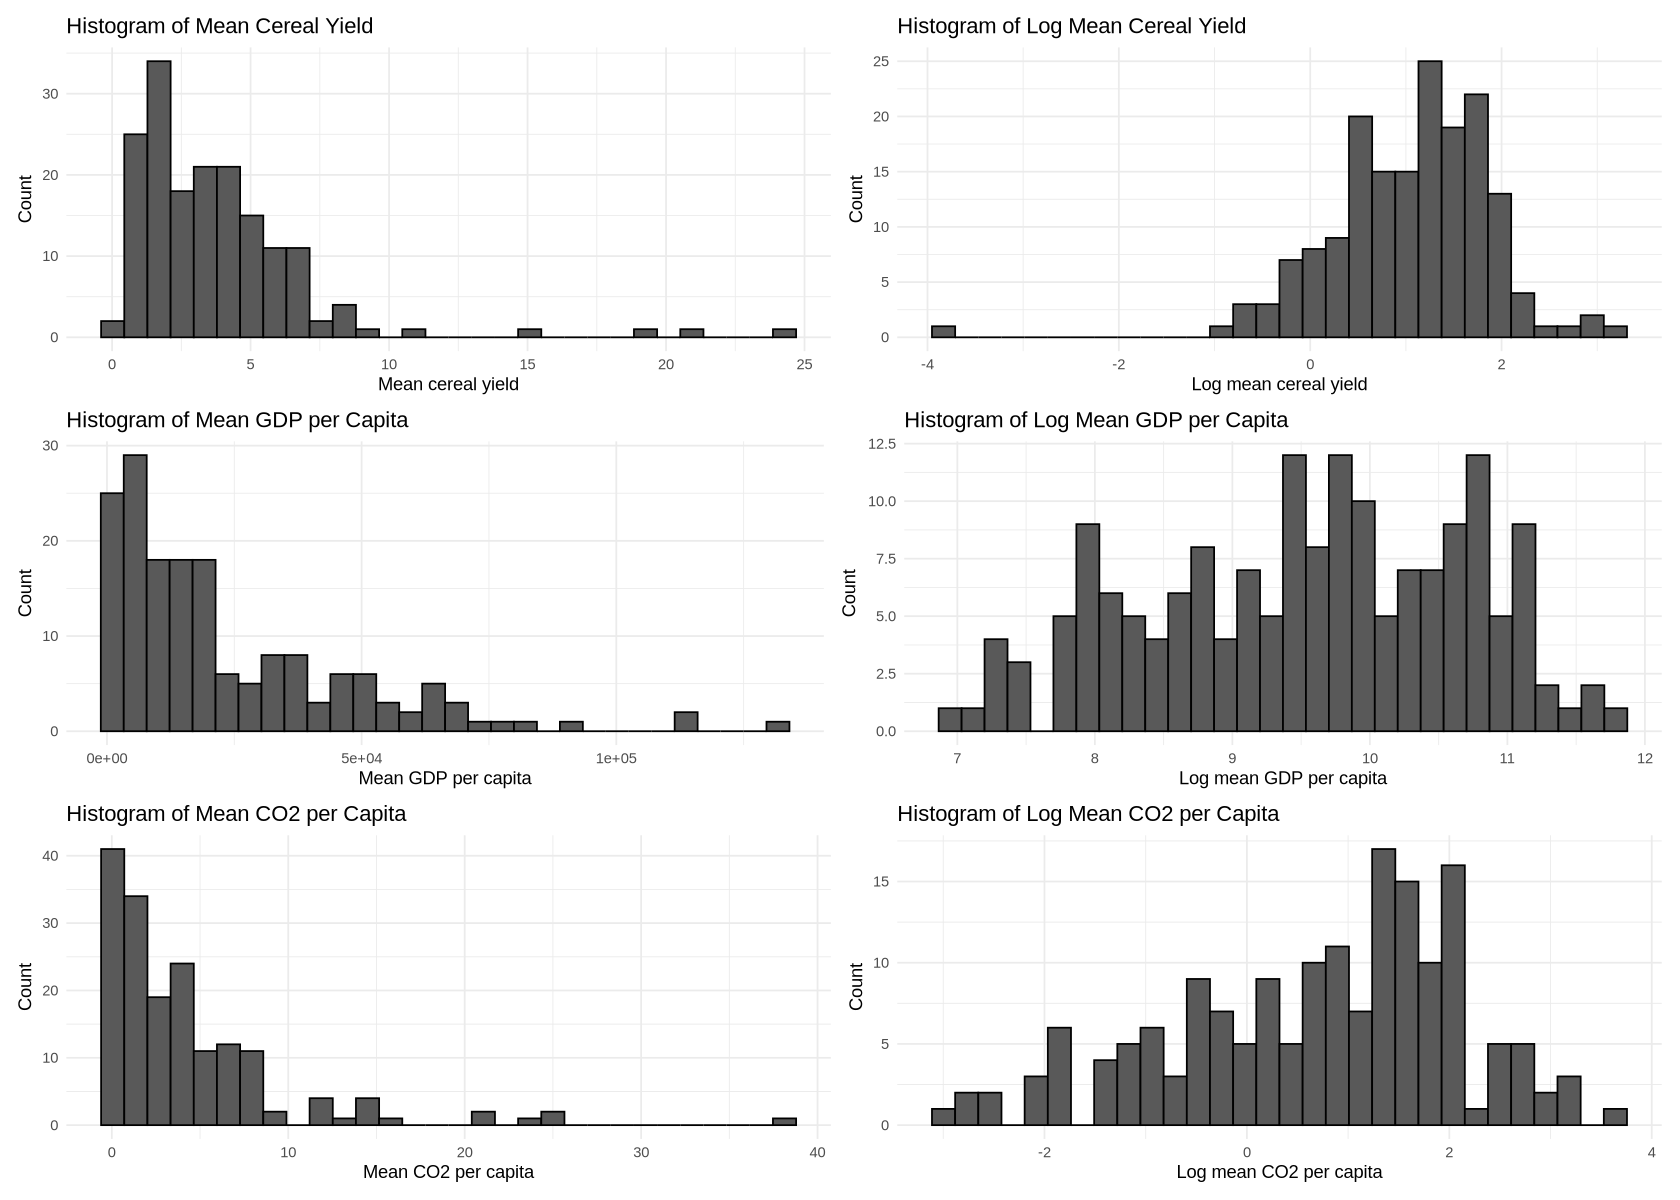

In [22]:
options(repr.plot.width = 14, repr.plot.height = 10)

library(ggplot2)
library(patchwork)

ploteda1 <- ggplot(model_df, aes(x = mean_yield)) +
  geom_histogram(bins = 30, colour = "black") +
  labs(
    x = "Mean cereal yield",
    y = "Count",
    title = "Histogram of Mean Cereal Yield"
  ) +
  theme_minimal()

ploteda2 <- ggplot(model_df, aes(x = log(mean_yield))) +
  geom_histogram(bins = 30, colour = "black") +
  labs(
    x = "Log mean cereal yield",
    y = "Count",
    title = "Histogram of Log Mean Cereal Yield"
  ) +
  theme_minimal()

ploteda3 <- ggplot(model_df, aes(x = mean_gdp)) +
  geom_histogram(bins = 30, colour = "black") +
  labs(
    x = "Mean GDP per capita",
    y = "Count",
    title = "Histogram of Mean GDP per Capita"
  ) +
  theme_minimal()

ploteda4 <- ggplot(model_df, aes(x = log(mean_gdp))) +
  geom_histogram(bins = 30, colour = "black") +
  labs(
    x = "Log mean GDP per capita",
    y = "Count",
    title = "Histogram of Log Mean GDP per Capita"
  ) +
  theme_minimal()

ploteda5 <- ggplot(model_df, aes(x = mean_co)) +
  geom_histogram(bins = 30, colour = "black") +
  labs(
    x = "Mean CO2 per capita",
    y = "Count",
    title = "Histogram of Mean CO2 per Capita"
  ) +
  theme_minimal()

ploteda6 <- ggplot(model_df, aes(x = log(mean_co))) +
  geom_histogram(bins = 30, colour = "black") +
  labs(
    x = "Log mean CO2 per capita",
    y = "Count",
    title = "Histogram of Log Mean CO2 per Capita"
  ) +
  theme_minimal()

(ploteda1 + ploteda2) / (ploteda3 + ploteda4) / (ploteda5 + ploteda6)

In [29]:
model_df_log <- model_df %>% mutate (log_mean_yield = log(mean_yield), log_mean_gdp = log(mean_gdp), log_mean_co = log(mean_co))
fit <- lm(log_mean_yield ~ log_mean_co + log_mean_gdp * region, data = model_df_log)
summary(fit)

options(repr.plot.width = 12, repr.plot.height = 7)


Call:
lm(formula = log_mean_yield ~ log_mean_co + log_mean_gdp * region, 
    data = model_df_log)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.2518 -0.2765  0.0246  0.2761  1.8813 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)   
(Intercept)                      -4.13894    1.57996  -2.620  0.00967 **
log_mean_co                      -0.21308    0.10267  -2.075  0.03958 * 
log_mean_gdp                      0.50562    0.18058   2.800  0.00575 **
regionAsia                        0.07208    1.39134   0.052  0.95875   
regionEurope                      2.59305    2.55593   1.015  0.31189   
regionNorth America              -1.69485    2.10510  -0.805  0.42197   
regionOceania                    -0.03259    2.04298  -0.016  0.98729   
regionSouth America              -2.33305    5.45740  -0.428  0.66960   
log_mean_gdp:regionAsia           0.07885    0.15321   0.515  0.60753   
log_mean_gdp:regionEurope        -0.17770    0.25123  -0.707 

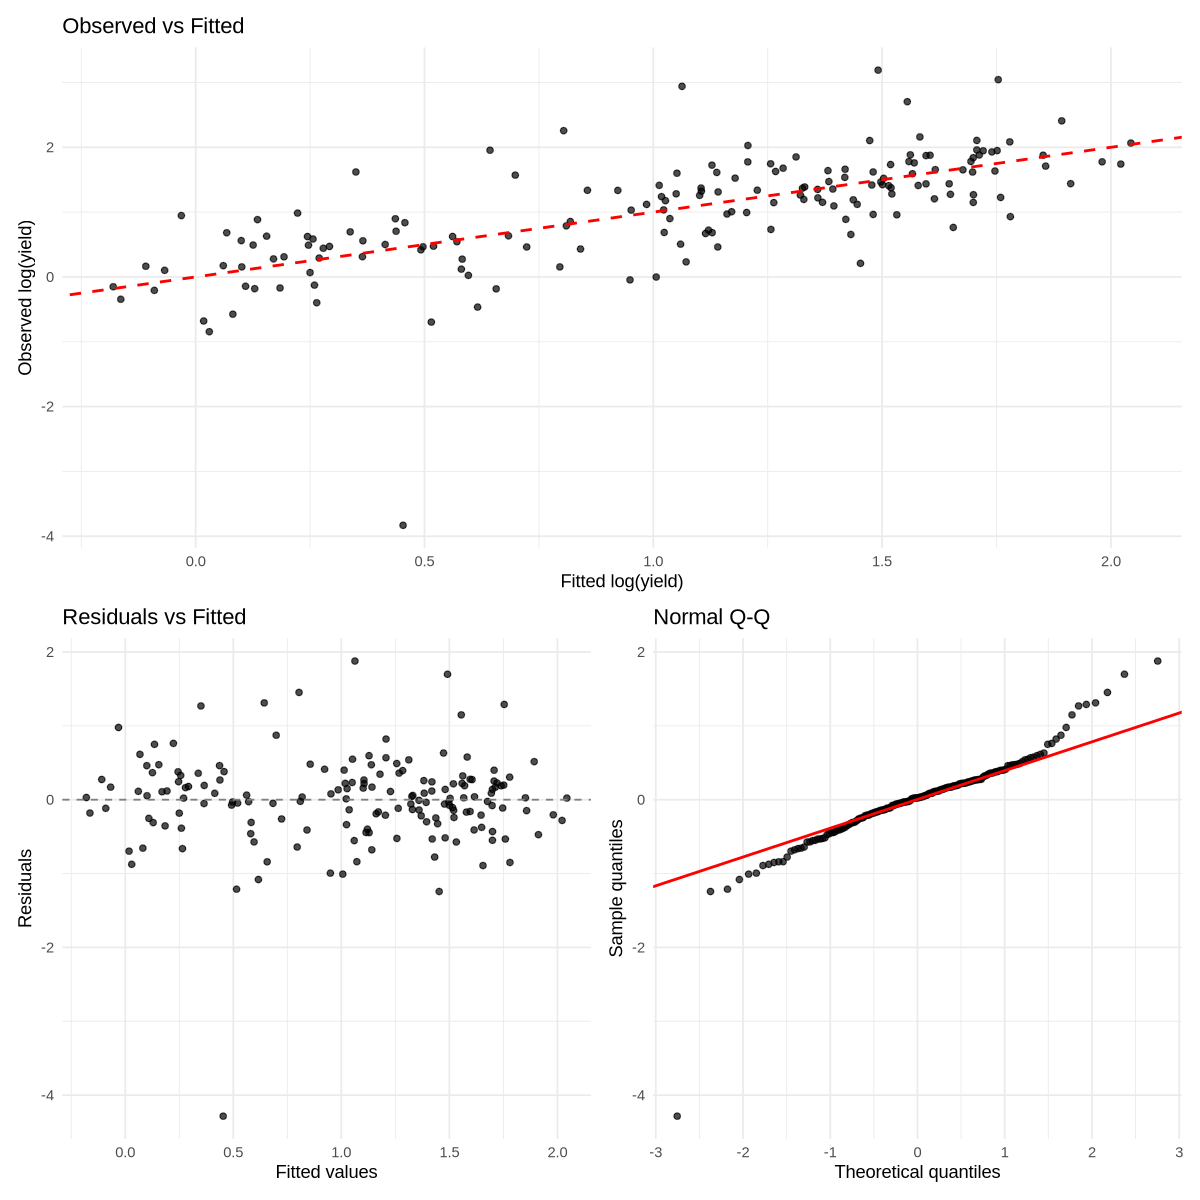

In [8]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot5 <- ggplot(data.frame(fitted   = fitted(fit),
                        observed = model_df_log$log_mean_yield),
             aes(x = fitted, y = observed)) +
  geom_point(alpha = 0.7) +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed", linewidth = 0.8) +
  labs(x = "Fitted log(yield)", y = "Observed log(yield)", title = "Observed vs Fitted") +
  theme_minimal()

plot6 <- ggplot(data.frame(fitted = fitted(fit),
                        resid  = resid(fit)),
             aes(x = fitted, y = resid)) +
  geom_point(alpha = 0.7) +
  geom_hline(yintercept = 0, color = "grey50", linetype = "dashed") +
  labs(x = "Fitted values", y = "Residuals", title = "Residuals vs Fitted") +
  theme_minimal()

plot7 <- ggplot(data.frame(resid = resid(fit)), aes(sample = resid)) +
  stat_qq(alpha = 0.7) +
  stat_qq_line(color = "red", linewidth = 0.8) +
  labs(x = "Theoretical quantiles", y = "Sample quantiles", title = "Normal Q-Q") +
  theme_minimal()

plot5 / (plot6 + plot7)


In [9]:
# Determine outlier (Visually, the minimum of the response has the largest residual
outlier <- model_df_log %>%
  filter(log_mean_yield == min(log_mean_yield)) %>%
  select(Entity)

model_df_log$std_resid <- rstandard(fit)

cooks_threshold = 4/nrow(model_df_log)

cat("Cook's threshold:", round(cooks_threshold, 4), "\n")

outlier_diagnostics <- model_df_log %>%
  mutate(
    cooks_d = cooks.distance(fit),
    std_resid = rstandard(fit)
  ) %>%
  filter(log_mean_yield == min(log_mean_yield, na.rm = TRUE)) %>%
  select(
    Entity,
    `Cook's Distance` = cooks_d,
    `Standardized Residual` = std_resid
  )

outlier_diagnostics

Cook's threshold: 0.0235 


Entity,Cook's Distance,Standardized Residual
<chr>,<dbl>,<dbl>
Cape Verde,0.1550602,-6.998686


In [34]:
#Remove from Dataset:
model_df_log_no_cape_verde <- model_df_log %>% filter(log_mean_yield != min(model_df_log$log_mean_yield))

# Refitting without outlier:
fit2 <- lm(log_mean_yield ~ log_mean_co + log_mean_gdp + region, data = model_df_log_no_cape_verde)
summary(fit2)



## Other models tested: 
fit_reject1 <- lm(log_mean_yield ~ log_mean_co + log_mean_gdp * region, data = model_df_log_no_cape_verde)
summary(fit_reject1)

fit_reject2 <- lm(log_mean_yield ~ log_mean_co * region, data = model_df_log_no_cape_verde)
summary(fit_reject2)

fit_reject3 <- lm(log_mean_yield ~ log_mean_co + region, data = model_df_log_no_cape_verde)
summary(fit_reject3)



Call:
lm(formula = log_mean_yield ~ log_mean_co + log_mean_gdp + region, 
    data = model_df_log_no_cape_verde)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.32418 -0.30089  0.01582  0.26031  1.87941 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)         -4.31521    0.94395  -4.571 9.60e-06 ***
log_mean_co         -0.17786    0.07805  -2.279  0.02399 *  
log_mean_gdp         0.54026    0.10601   5.096 9.61e-07 ***
regionAsia           0.63117    0.13329   4.735 4.77e-06 ***
regionEurope         0.44309    0.16503   2.685  0.00801 ** 
regionNorth America  0.26603    0.15663   1.698  0.09136 .  
regionOceania        0.45004    0.21589   2.085  0.03869 *  
regionSouth America  0.63287    0.19073   3.318  0.00112 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5194 on 161 degrees of freedom
Multiple R-squared:  0.5493,	Adjusted R-squared:  0.5297 
F-statistic: 28.03 on 7 and 161 DF


Call:
lm(formula = log_mean_yield ~ log_mean_co + log_mean_gdp * region, 
    data = model_df_log_no_cape_verde)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.33912 -0.28609  0.01554  0.25813  1.88030 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      -4.92321    1.32444  -3.717  0.00028 ***
log_mean_co                      -0.22120    0.08585  -2.577  0.01090 *  
log_mean_gdp                      0.60884    0.15150   4.019 9.08e-05 ***
regionAsia                        0.76973    1.16639   0.660  0.51028    
regionEurope                      3.35156    2.13905   1.567  0.11918    
regionNorth America              -1.00276    1.76211  -0.569  0.57013    
regionOceania                     0.68461    1.71039   0.400  0.68951    
regionSouth America              -1.60644    4.56393  -0.352  0.72532    
log_mean_gdp:regionAsia          -0.01434    0.12859  -0.112  0.91133    
log_mean_gdp:regionEurope  


Call:
lm(formula = log_mean_yield ~ log_mean_co * region, data = model_df_log_no_cape_verde)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.38494 -0.30629  0.06079  0.30347  1.91297 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      0.455280   0.094850   4.800 3.67e-06 ***
log_mean_co                      0.138579   0.064757   2.140 0.033902 *  
regionAsia                       0.608681   0.154716   3.934 0.000125 ***
regionEurope                     0.977327   0.395871   2.469 0.014628 *  
regionNorth America              0.457943   0.201406   2.274 0.024337 *  
regionOceania                    0.348992   0.249881   1.397 0.164494    
regionSouth America              0.754083   0.416162   1.812 0.071898 .  
log_mean_co:regionAsia           0.057472   0.095382   0.603 0.547682    
log_mean_co:regionEurope        -0.042352   0.230546  -0.184 0.854483    
log_mean_co:regionNorth America -0.005367   0.1


Call:
lm(formula = log_mean_yield ~ log_mean_co + region, data = model_df_log_no_cape_verde)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.46046 -0.29889  0.02127  0.30817  1.91953 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)          0.47809    0.08585   5.569 1.05e-07 ***
log_mean_co          0.16818    0.04134   4.068 7.40e-05 ***
regionAsia           0.62040    0.14318   4.333 2.57e-05 ***
regionEurope         0.83304    0.15709   5.303 3.68e-07 ***
regionNorth America  0.39875    0.16593   2.403   0.0174 *  
regionOceania        0.39358    0.23163   1.699   0.0912 .  
regionSouth America  0.86318    0.19907   4.336 2.54e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.558 on 162 degrees of freedom
Multiple R-squared:  0.4766,	Adjusted R-squared:  0.4572 
F-statistic: 24.58 on 6 and 162 DF,  p-value: < 2.2e-16


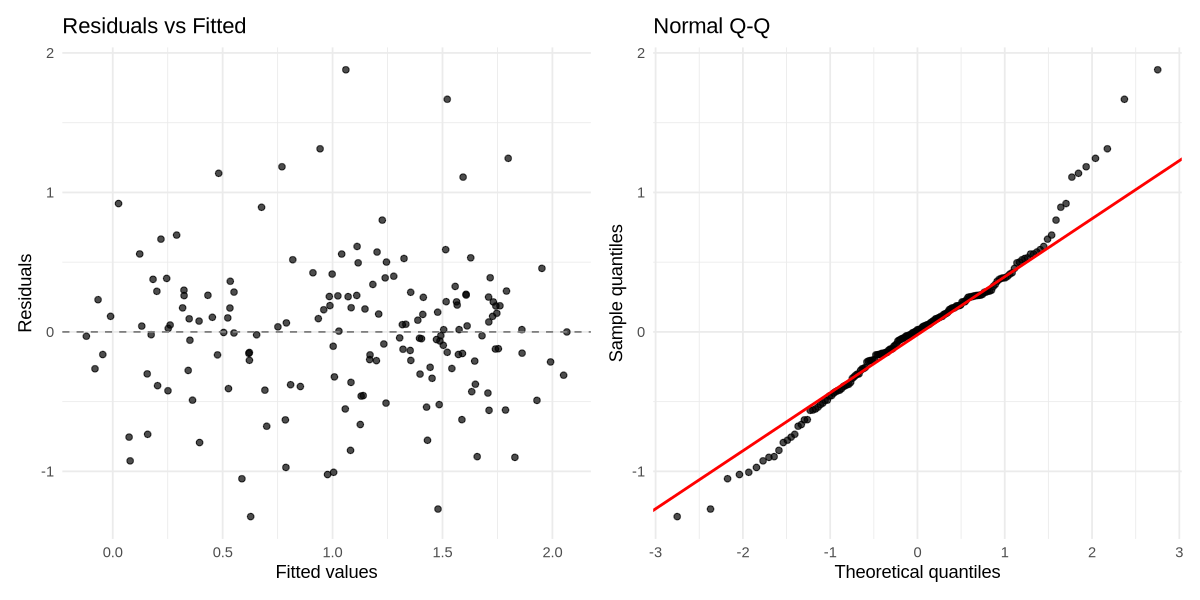

In [32]:
# Visualizing after removing the outlier:
options(repr.plot.width = 10, repr.plot.height = 5)
# Residuals vs Fitted
plot8 <- ggplot(data.frame(fitted = fitted(fit2), resid = resid(fit2)),
             aes(x = fitted, y = resid)) +
  geom_point(alpha = 0.7) +
  geom_hline(yintercept = 0, color = "grey50", linetype = "dashed") +
  labs(x = "Fitted values", y = "Residuals", title = "Residuals vs Fitted") +
  theme_minimal()

# Normal Q-Q
plot9 <- ggplot(data.frame(resid = resid(fit2)), aes(sample = resid)) +
  stat_qq(alpha = 0.7) +
  stat_qq_line(color = "red", linewidth = 0.8) +
  labs(x = "Theoretical quantiles", y = "Sample quantiles", title = "Normal Q-Q") +
  theme_minimal()

plot8 + plot9

In [ ]:
#Pearson:
cor(model_df_log_no_cape_verde$log_mean_gdp,
    model_df_log_no_cape_verde$log_mean_co,
    use = "complete.obs")

#VIF
vif(fit2)